Notebook ini melakukan analisis data eksplorasi yang menyeluruh pada dataset untuk memahami pola data, distribusi, dan hubungan antar fitur.

## Import Library

Tahap paling pertama dilakukan dengan menambahkan import library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import probscale
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

## Pemuatan Data dan Eksplorasi Awal

Selanjutnya mulai dengan memuat dataset dan memeriksa struktur, dimensi, serta statistik dasarnya.

### Muat Dataset

In [2]:
df = pd.read_csv('../data/raw/silica_data.csv')

### Periksa Jumlah Data dan Kolom

In [3]:
df.shape

(737453, 24)

### Periksa Informasi Dataframe

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date                          737453 non-null  object
 1   % Iron Feed                   737453 non-null  object
 2   % Silica Feed                 737453 non-null  object
 3   Starch Flow                   737453 non-null  object
 4   Amina Flow                    737453 non-null  object
 5   Ore Pulp Flow                 737453 non-null  object
 6   Ore Pulp pH                   737453 non-null  object
 7   Ore Pulp Density              737453 non-null  object
 8   Flotation Column 01 Air Flow  737453 non-null  object
 9   Flotation Column 02 Air Flow  737453 non-null  object
 10  Flotation Column 03 Air Flow  737453 non-null  object
 11  Flotation Column 04 Air Flow  737453 non-null  object
 12  Flotation Column 05 Air Flow  737453 non-null  object
 13 

### Periksa Nilai Beberapa Sampel

In [5]:
df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


### Periksa Statistika Deksriptif Data

In [7]:
df.describe()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453,737453,737453,737453,737453,737453,737453,737453,737453,737453,...,737453,737453,737453,737453,737453,737453,737453,737453,737453,737453
unique,4097,278,293,409317,319416,180189,131143,105805,43675,80442,...,86819,299573,331189,322315,309264,276051,301502,295667,38696,55569
top,2017-09-09 23:00:00,"64,03","6,26","2562,5","534,668","402,246","10,0591","1,75","299,927","255,322",...,"299,487","452,441","608,887","601,06","491,406","513,879","474,37","479,478","65,44","2,08"
freq,180,142560,142560,690,959,1735,1509,3214,13683,1487,...,3405,1013,817,989,733,709,746,905,16920,17100


### Pemeriksaan Nilai Null

In [8]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Percentage', ascending=False)

missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing Percentage


### Periksa Nilai Duplikat

In [9]:
df.duplicated().sum()

np.int64(1171)

Key Insight(s) untuk Tahapan Pemuatan Data dan Eksplorasi Awal: 
- **Periksa Jumlah Data dan Kolom**: Terdapat lebih dari 700k data dengan total 24 kolom.
- **Periksa Informasi Dataframe**: Terlihat bahwa setiap kolom bertipe data object atau string. Terdapat juga kolom date yang perlu diganti ke format datetime Pandas untuk dapat diolah. Kolom lain seharusnya bernilai bertipe data numerik.
- **Periksa Nilai Beberapa Sampel**: Dari pemeriksaan sampel data, terlihat bahwa kolom-kolom yang seharusnya numerik namun bertipe data object memiliki penggunaan tanda koma. Tanda ini perlu diganti dengan titik untuk dapat dikonversi ke tipe data numerik oleh Pandas.
- **Periksa Statistika Deskriptif Data**: Terdapat variasi nilai yang cukup besar pada beberapa fitur numerik. Target variable (silica) memiliki distribusi yang miring (skewed) dengan nilai skewness positif, menunjukkan mayoritas nilai berada di bagian bawah rentang data dengan beberapa outlier di sisi nilai tinggi. Nilai rata-rata dan median silica yang berbeda juga mengkonfirmasi adanya ketidaksimetrisan distribusi.
- **Periksa Nilai Kosong dan Duplikat**: Tidak terdapat nilai kosong pada dataset, namun terdapat nilai duplikat.


## Pemrosesan Data Awal

Sebelum melakukan analisis, tahap ini akan melakukan langkah-langkah preprocessing awal yang diperlukan untuk membantu EDA dengan:
- Menghapus record duplikat untuk mencegah bias dalam analisis
- Mengubah kolom tanggal ke format datetime yang tepat untuk analisis berbasis waktu
- Menstandardisasi nama kolom dengan mengubah ke huruf kecil dan mengganti spasi dengan underscore
- Mengubah kolom numerik dari format string ke nilai numerik dengan tipe data float dengan mengganti tanda koma menjadi titik
- Mengidentifikasi kolom fitur dan variabel target untuk analisis selanjutnya

### Penghapus Data Duplikat

In [10]:
# Drop duplicates
df.drop_duplicates(inplace=True)

### Konversi Kolom Date ke Format Datetime Pandas

In [11]:
# Parse date column to datetime format
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S')

In [12]:
df.rename(columns={'date': 'datetime'}, inplace=True)

### Standardisasi Penamaan Kolom dari Dataset

In [13]:
# Lower columns name and replace space with underscores
df.columns = [clm.replace(' ', '_').lower() for clm in df.columns]

### Konversi Tipe Data Kolom Numerik dari Object ke Float

In [14]:
# Convert numeric columns to float
for column in df.columns[1:]:
    df[column]=df[column].str.replace(',','.').astype(float)

### Periksa Ulang Informasi Dataframe

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 736282 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   datetime                      736282 non-null  datetime64[ns]
 1   %_iron_feed                   736282 non-null  float64       
 2   %_silica_feed                 736282 non-null  float64       
 3   starch_flow                   736282 non-null  float64       
 4   amina_flow                    736282 non-null  float64       
 5   ore_pulp_flow                 736282 non-null  float64       
 6   ore_pulp_ph                   736282 non-null  float64       
 7   ore_pulp_density              736282 non-null  float64       
 8   flotation_column_01_air_flow  736282 non-null  float64       
 9   flotation_column_02_air_flow  736282 non-null  float64       
 10  flotation_column_03_air_flow  736282 non-null  float64       
 11  flotation_column_0

### Identifikasi Target dan Fitur

In [16]:
NUM_FEATURES = df.columns[1:-1]

In [17]:
NUM_FEATURES

Index(['%_iron_feed', '%_silica_feed', 'starch_flow', 'amina_flow',
       'ore_pulp_flow', 'ore_pulp_ph', 'ore_pulp_density',
       'flotation_column_01_air_flow', 'flotation_column_02_air_flow',
       'flotation_column_03_air_flow', 'flotation_column_04_air_flow',
       'flotation_column_05_air_flow', 'flotation_column_06_air_flow',
       'flotation_column_07_air_flow', 'flotation_column_01_level',
       'flotation_column_02_level', 'flotation_column_03_level',
       'flotation_column_04_level', 'flotation_column_05_level',
       'flotation_column_06_level', 'flotation_column_07_level',
       '%_iron_concentrate'],
      dtype='object')

In [18]:
TARGET = df.columns[-1]
TARGET

'%_silica_concentrate'

In [19]:
df[NUM_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
%_iron_feed,736282.0,56.298307,5.160365,42.740000,52.670000,56.08000,59.72000,65.78000
%_silica_feed,736282.0,14.648984,6.810741,1.310000,8.940000,13.85000,19.60000,33.40000
starch_flow,736282.0,2869.636615,1216.017896,0.002026,2075.070000,3020.23000,3728.93000,6300.23000
amina_flow,736282.0,488.165523,91.254428,241.669000,431.835848,504.35250,553.33575,739.53800
ore_pulp_flow,736282.0,397.570736,9.705444,376.249000,394.248000,399.23800,402.96700,418.64100
ore_pulp_ph,736282.0,9.767315,0.387176,8.753340,9.527050,9.79746,10.03780,10.80810
ore_pulp_density,736282.0,1.680424,0.069206,1.519820,1.647390,1.69758,1.72838,1.85325
flotation_column_01_air_flow,736282.0,280.119813,29.633831,175.510000,250.278000,299.34100,300.14700,373.87100
flotation_column_02_air_flow,736282.0,277.121249,30.157126,175.156000,250.448000,296.20200,300.68600,375.99200
flotation_column_03_air_flow,736282.0,281.052538,28.571077,176.469000,250.847000,298.69000,300.38500,364.34600


In [20]:
df[TARGET].describe()

count    736282.000000
mean          2.327270
std           1.125616
min           0.600000
25%           1.440000
50%           2.000000
75%           3.010000
max           5.530000
Name: %_silica_concentrate, dtype: float64

Key Insight(s) untuk Tahap Pemrosesan Data Awal:
- Proses preprocessing awal berhasil menghapus duplikasi data untuk mencegah bias dalam analisis.
- Kolom tanggal telah dikonversi ke format datetime Pandas dan diubah namanya menjadi 'datetime', sehingga memungkinkan analisis temporal nantinya.
- Standardisasi nama kolom telah dilakukan dengan mengubah semua nama ke huruf kecil dan mengganti spasi dengan underscore untuk konsistensi.
- Konversi tipe data berhasil dilakukan dengan mengganti tanda koma menjadi titik pada kolom numerik dan mengubahnya ke tipe float.
- Identifikasi fitur numerik dan variabel target telah dilakukan untuk memudahkan analisis selanjutnya.
- Setelah preprocessing, semua kolom numerik memiliki tipe data yang sesuai (float), sehingga memungkinkan perhitungan statistik dan visualisasi data yang akurat.

## Exploratory Data Analysis

## Exploratory Data Analysis
Setelah melakukan pemrosesan data awal, tahap selanjutnya adalah analisis eksplorasi data (EDA). Tahap ini bertujuan untuk memahami karakteristik data secara mendalam melalui visualisasi dan analisis statistik. Beberapa analisis yang akan dilakukan pada tahap ini antara lain:
- **Analisis Distribusi Data**: Menggunakan histogram dengan kurva KDE untuk memahami bentuk, kecenderungan pusat, dan sebaran setiap variabel numerik. Ini membantu mengidentifikasi outlier potensial, kemiringan distribusi, dan pola data secara keseluruhan.
- **Analisis Variabel Target**: Melakukan analisis mendalam pada konsentrasi silika (variabel target) menggunakan beberapa teknik visualisasi seperti histogram, boxplot, plot ECDF, dan probability plot. Analisis ini juga mencakup pengamatan pola temporal dan agregasi bulanan untuk mendeteksi pola musiman.
- **Analisis Outlier**: Mengidentifikasi dan menganalisis outlier menggunakan metode IQR (Interquartile Range) untuk memahami seberapa besar pengaruh outlier terhadap distribusi data.
- **Analisis Korelasi**: Menghitung dan memvisualisasikan matriks korelasi antara semua variabel numerik menggunakan heatmap untuk mengidentifikasi hubungan antar variabel yang dapat mempengaruhi kinerja model prediktif nantinya.

Hasil dari analisis eksplorasi data ini akan memberikan wawasan tentang karakteristik dataset dan membantu dalam pengambilan keputusan untuk pemodelan pada tahap selanjutnya.

### Data Distribution Analysis

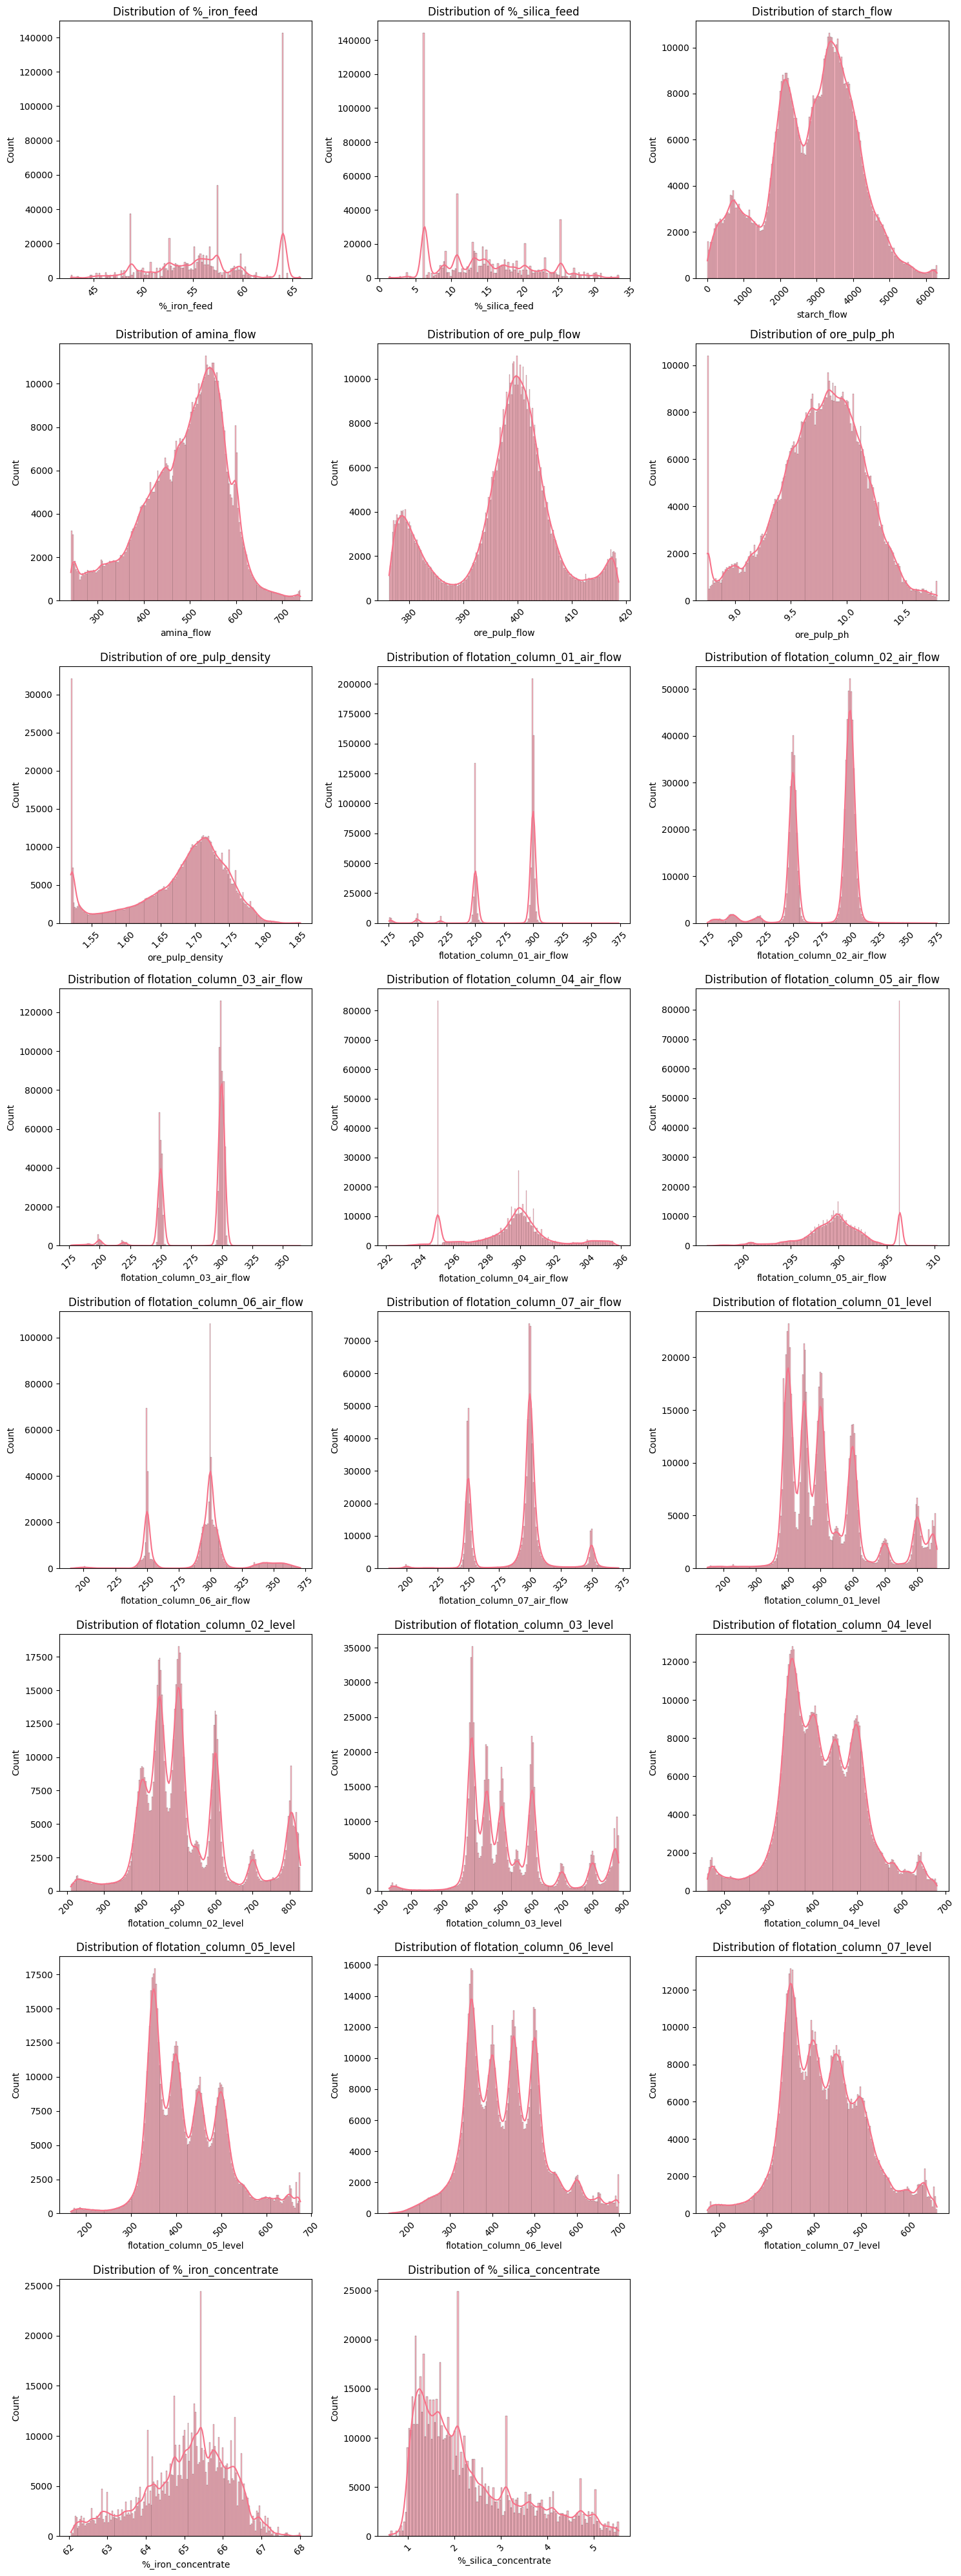

In [21]:
numeric_columns = df.columns[1:]
n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, col in enumerate(numeric_columns):
    if i < len(axes):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].tick_params(axis='x', rotation=45)

# Hide extra subplots
for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### Target Variable Analysis

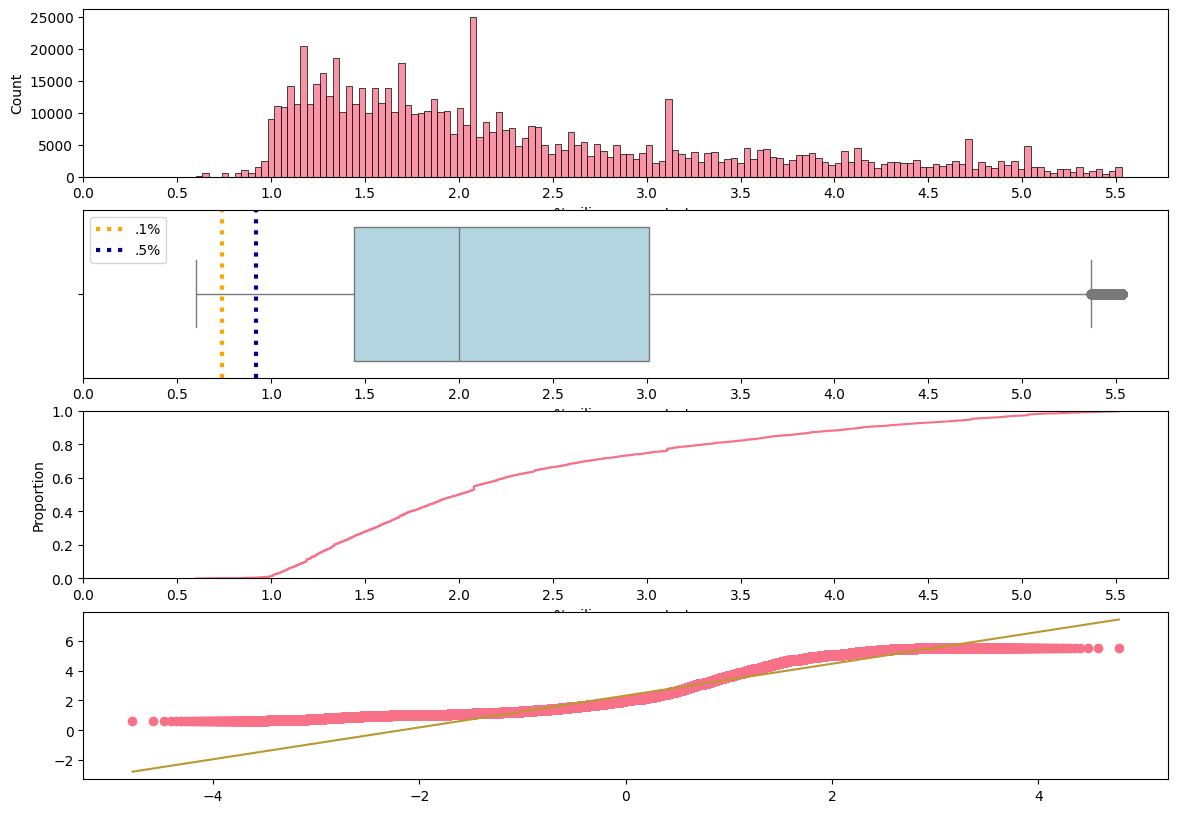

In [22]:
fig,ax=plt.subplots(4, 1, figsize=(14,10))

sns.histplot(df[TARGET], ax=ax[0])
sns.boxplot(x=df[TARGET], color='lightblue', saturation=0.8, ax=ax[1])
ax[1].axvline(np.percentile(df[TARGET],.1), label='.1%', c='orange', linestyle=':', linewidth=3)
ax[1].axvline(np.percentile(df[TARGET],.5), label='.5%', c='darkblue', linestyle=':', linewidth=3)
ax[1].legend()
sns.ecdfplot(df[TARGET], ax=ax[2])
ax[0].set_xticks(np.arange(0, df[TARGET].max(), .5))
ax[1].set_xticks(np.arange(0, df[TARGET].max(), .5))
ax[2].set_xticks(np.arange(0, df[TARGET].max(), .5))
fig = probscale.probplot(
    df[TARGET],
    ax=ax[3],
    plottype='qq',
    bestfit=True
)
plt.show()
plt.show()

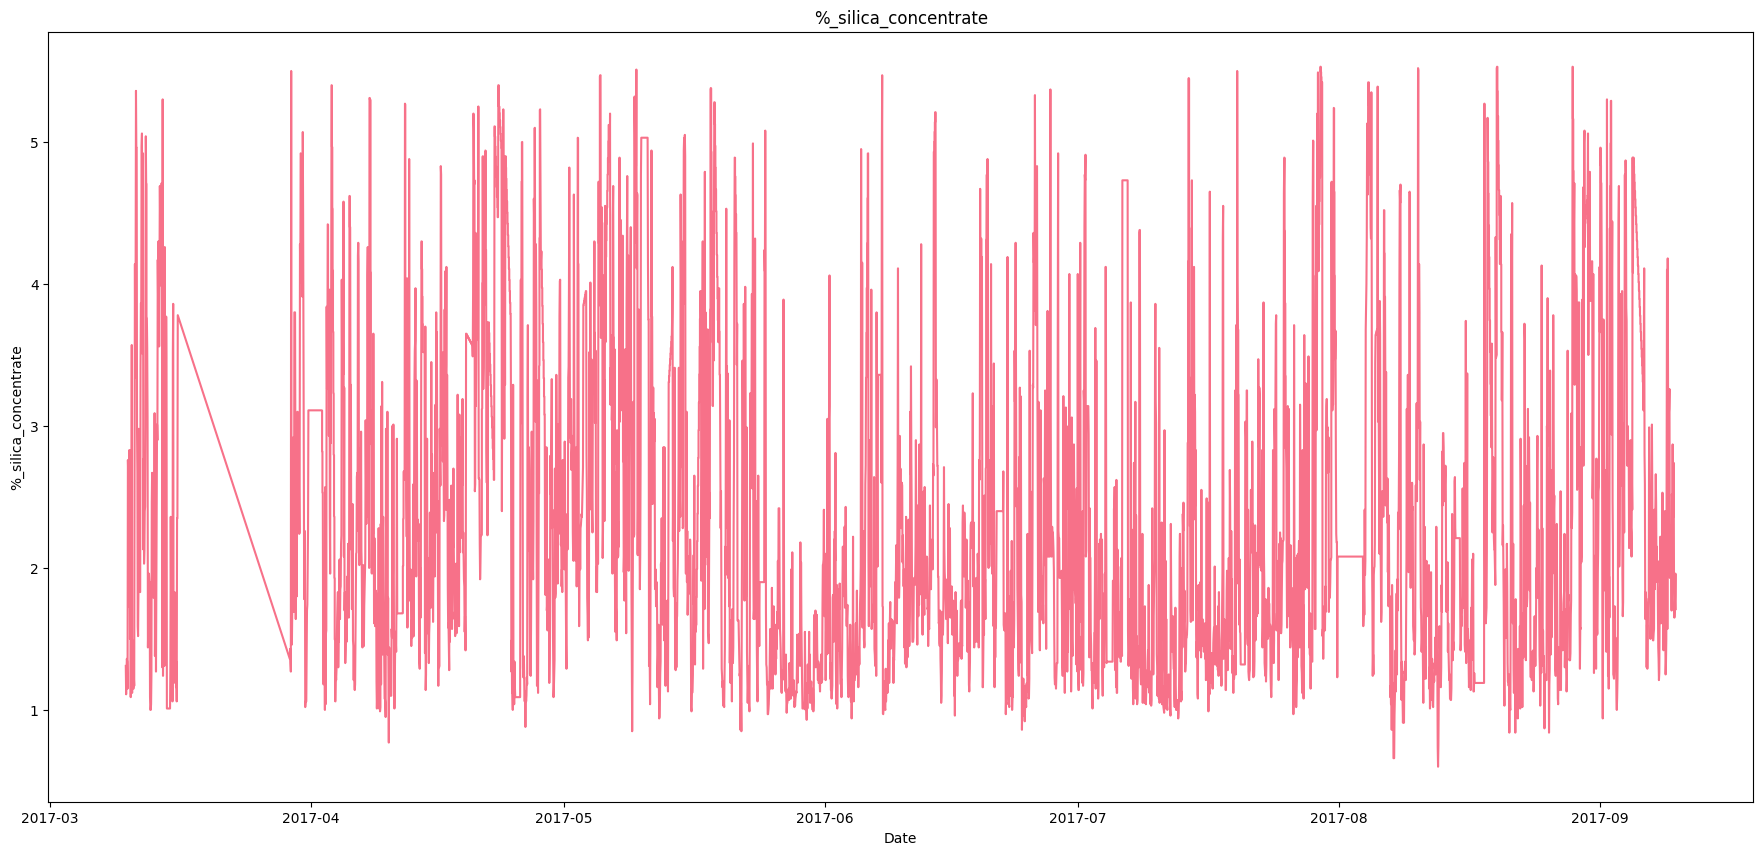

In [23]:
plt.figure(figsize=(22,10))
plt.plot(df.datetime, df[TARGET])
plt.title(f"{TARGET}")
plt.xlabel("Date")
plt.ylabel(f"{TARGET}")
plt.show()

In [24]:
print(f"Skew of target: {df[TARGET].skew():.3f}")

Skew of target: 0.970


In [25]:
df[TARGET].groupby(df.datetime.dt.to_period('M')).agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
datetime,,,,
2017-03,2.513703,2.240,1.00,5.50
2017-04,2.635433,2.460,0.77,5.40
2017-05,2.494664,2.090,0.85,5.51
2017-06,2.045997,1.820,0.86,5.47
2017-07,2.057320,1.660,0.94,5.53
2017-08,2.245712,2.040,0.60,5.53
2017-09,2.683287,2.455,0.94,5.30


### Outliers Analysis

In [26]:
def get_distribution_metrics(data, title='', prec=2):
    ''' Calculate distribution metrics without plotting '''
    
    # Quartiles and IQR
    q1, q3 = np.percentile(data.dropna(), [25, 75])
    iqr = q3 - q1
    
    # Outlier boundaries (1.5 * IQR rule)
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Actual whisker values (data points within bounds)
    valid_data = data.dropna()
    whisker_high = valid_data[valid_data <= upper_bound]
    whisker_low = valid_data[valid_data >= lower_bound]
    actual_upper_whisker = np.max(whisker_high) if len(whisker_high) > 0 else upper_bound
    actual_lower_whisker = np.min(whisker_low) if len(whisker_low) > 0 else lower_bound
    
    # Count outliers
    outliers = valid_data[(valid_data < actual_lower_whisker) | (valid_data > actual_upper_whisker)]
    
    metrics = {
        'Variable': title if title else 'Data',
        'Q1 (25th percentile)': round(q1, prec),
        'Q3 (75th percentile)': round(q3, prec),
        'IQR': round(iqr, prec),
        'Lower Bound (Q1 - 1.5*IQR)': round(lower_bound, prec),
        'Upper Bound (Q3 + 1.5*IQR)': round(upper_bound, prec),
        'Actual Lower Whisker': round(actual_lower_whisker, prec),
        'Actual Upper Whisker': round(actual_upper_whisker, prec),
        'Number of Outliers': len(outliers),
        'Outlier Percentage': round((len(outliers) / len(valid_data)) * 100, prec),
    }
    
    return metrics

In [27]:
target_metrics = get_distribution_metrics(df[TARGET], TARGET)
print(f"\nTarget Variable ({TARGET}) Distribution Summary:")
print("=" * 60)
for key, value in target_metrics.items():
    print(f"{key}: {value}")


Target Variable (%_silica_concentrate) Distribution Summary:
Variable: %_silica_concentrate
Q1 (25th percentile): 1.44
Q3 (75th percentile): 3.01
IQR: 1.57
Lower Bound (Q1 - 1.5*IQR): -0.91
Upper Bound (Q3 + 1.5*IQR): 5.36
Actual Lower Whisker: 0.6
Actual Upper Whisker: 5.36
Number of Outliers: 4757
Outlier Percentage: 0.65


### Correlation Analysis

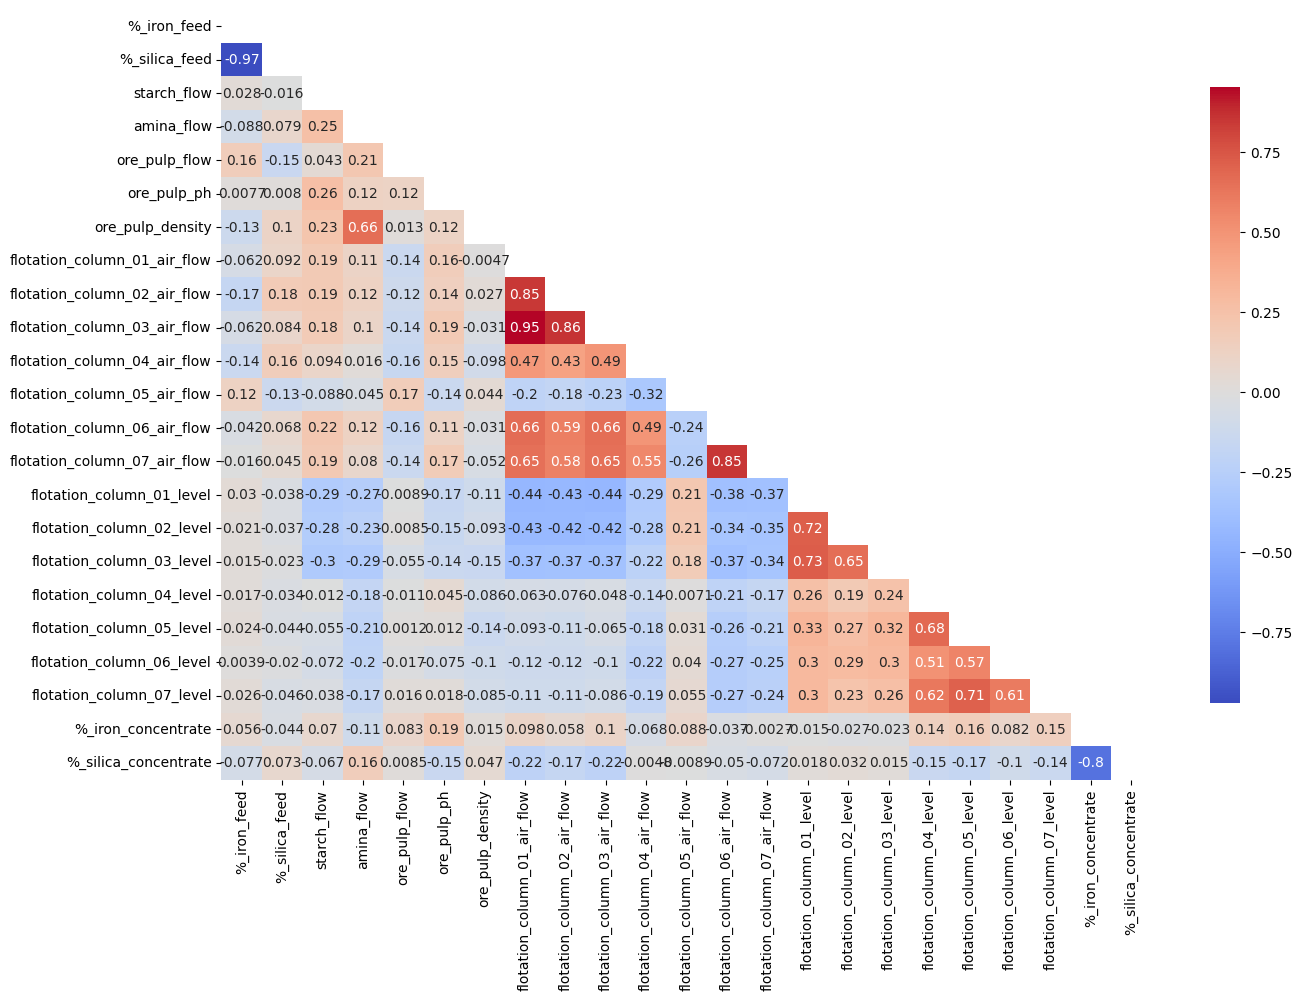

In [28]:
corrMatrix = df[df.columns[1:]].corr(method='pearson', min_periods=1)
plt.figure(figsize=(15,10))
mask = np.triu(np.ones_like(corrMatrix, dtype=bool))
ax = sns.heatmap(corrMatrix, mask=mask, annot=True, cbar_kws={"shrink": .8}, cmap='coolwarm')
plt.show()

Key Insight(s) untuk Tahap Exploratory Data Analysis:

**Analisis Distribusi Data:**
- Sebagian besar fitur memiliki distribusi multimodal (memiliki beberapa puncak).
- Variabel aliran udara pada kolom flotasi (flotation_column_air_flow) menunjukkan pola yang sangat distingtif, dengan beberapa menunjukkan distribusi bimodal atau trimodal.
- Beberapa variabel memiliki kemiringan (skewness) yang tinggi, namun beberapa juga memiliki distribusi yang mendekati normal.
- Level pada kolom flotasi menunjukkan distribusi yang kompleks dengan beberapa mode berbeda, menandakan variasi dalam pengaturan proses.
- Walaupun masih ada beberapa fitur yang jauh dari distribusi normal, adanya variansi dari variabel membuat StandardScaler menjadi pilihan yang lebih tepat daripada MinMaxScaler di pemrosesan data selanjutnya.

**Analisis Variabel Target:**
- Konsentrasi silika (target variable) menunjukkan distribusi yang miring ke kanan (right-skewed) dengan nilai skewness 1.821, di mana mayoritas nilai berada pada rentang 1-3%.
- Boxplot mengkonfirmasi adanya outlier pada bagian atas (nilai >5.36%), yang merepresentasikan kondisi di mana proses flotasi kurang efisien.
- Grafik deret waktu (time series) menunjukkan volatilitas tinggi dalam konsentrasi silika, dengan pola fluktuasi yang tidak teratur.
- Agregasi bulanan menunjukkan nilai rata-rata tertinggi pada bulan September (2.68) dan terendah pada Juni (2.05), dengan median terendah pada Juli (1.66), yang mungkin mengindikasikan pengaruh musiman terhadap efisiensi proses.
- Range nilai minimum-maksimum silika cukup lebar (0.6-5.53), menunjukkan variabilitas tinggi dalam performa proses.

**Analisis Outlier:**
- Dari metrik distribusi, variabel target memiliki Q1 pada 1.44 dan Q3 pada 3.01, dengan IQR sebesar 1.57.
- Batas bawah untuk outlier secara teoritis adalah -0.91, namun nilai aktual terendah adalah 0.6.
- Batas atas untuk outlier adalah 5.36, dengan outlier merepresentasikan kondisi di mana silika tidak terpisahkan dengan baik.
- Terdapat 4.757 outlier yang merepresentasikan 0.65% dari keseluruhan data, mayoritas berada di sisi nilai tinggi (>5.36%).
- Persentase outlier yang relatif kecil namun signifikan ini perlu ditangani pada tahap pemrosesan data selanjutnya.
- Adanya outlier membuat StandardScaler menjadi pilihan yang makin tepat karena lebih robust terhadap outlier dibanding MinMaxScaler yang sensitif terhadap outlier.

**Analisis Korelasi:**
- Terdapat korelasi negatif yang kuat (-0.8) antara konsentrasi silika dan konsentrasi besi (%_iron_concentrate).
- Beberapa level kolom flotasi menunjukkan korelasi cukup kuat satu sama lain (>0.7), mengindikasikan keterkaitan dalam pengaturan proses.
- Variabel %_silica_feed memiliki korelasi positif moderat dengan variabel target.
- Parameter proses tertentu seperti flotation_column_07_air_flow menunjukkan korelasi moderat dengan variabel target, yang dapat menjadi fitur penting dalam pemodelan.
- Secara keseluruhan, fitur-fitur yang ada sudah lumayan untuk digunakan pada prediksi target, namun feature engineering masih diperlukan untuk membuat fitur yang lebih bagus lagi dalam memprediksi target.

## Simpan Data

Terakhir data yang sudah dipersihkan ini disimpan untuk diproses lebih lanjut yang sesuai untuk tahap pemodelan nantinya

In [ ]:
import os
if not os.path.exists('../data/interim'):
    os.makedirs('../data/interim')
df.to_csv('../data/interim/silica_data_cleaned.csv', index=False)

# Checklist Revisi Submission
- [ ] Tambahkan penjelasan di setiap tahapan proyek menggunakan text cell (Markdown). Jelaskan proses yang dilakukan dan hasil dari proses tersebut.
    - [x] Pada notebook 01_EDA.ipynb
    - [ ] Pada notebook 02_data_preparation.ipynb
    - [ ] Pada notebook 03_model.ipynb
- [ ] Gunakan bahasa Indonesia dalam penulisan laporan.
- [x] Jelaskan seluruh tahap preprocessing secara urut.
  - [x] Contoh: `drop_duplicates`
  - [x] Contoh: parsing kolom tanggal (`parse date column`)|
- [ ] Jelaskan cara kerja masing-masing algoritma/model yang digunakan.
- [ ] Gunakan heading markdown untuk struktur yang rapi pada penjelasan model:
  - `## Modeling`
  - `### Model 1`, `### Model 2`, dst.
- [ ] Jelaskan setiap parameter yang digunakan pada model.
- [ ] Tambahkan kelebihan dan kekurangan model.
- [ ] Perlihatkan hasil evaluasi baseline model.
- [ ] Pindahkan hasil baseline model dari bagian modelling ke bagian evaluasi.
- [ ] Tambahkan kesimpulan dari problem statement di akhir tahap evaluasi.